# Order Flow (OF) 特征构建

本 notebook 把 `book_snapshot_25` 订单簿数据转换成论文定义的 **Order Flow (OF)** 特征，
并计算预测目标（mid-price 的多步 return），做时序切分与标准化，最后存盘供建模使用。

**精确遵循论文的 6 步构建**（详见 `data_download.ipynb` 第 7 节）：
1. LOB 快照（取前 10 档）
2. bid 侧订单流 $\text{bOF}$（价格上移/不变/下移 三情况）
3. ask 侧订单流 $\text{aOF}$（符号与 bid 相反）
4. 拼接成 $\text{OF}_t \in \mathbb{R}^{20}$
5. 堆叠成 $100 \times 20$ 输入矩阵（窗口化，建模时即时生成）
6. Winsorization + Z-score（只用训练集统计量）

**内存策略：** 2.4M 个快照若全部展开成 `(N,100,20)` 需 ~19GB。所以这里只保存紧凑的
逐市场 OF 数组 `(n,20)`（~194MB）+ 归一化参数，窗口在建模时用滑窗函数即时生成。

## 0. 环境与配置

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 4)
print('imports ok')

imports ok


In [2]:
# ── 配置 ──────────────────────────────────────────────────────────────────────
CHANNEL  = "book_snapshot_25"
RAW_DIR  = Path("../data/raw") / CHANNEL
PROC_DIR = Path("../data/processed/of")
PROC_DIR.mkdir(parents=True, exist_ok=True)

N_LEVELS  = 10          # 论文用每侧 10 档
OF_DIM    = N_LEVELS * 2  # = 20（bid 10 + ask 10）
W         = 100         # lookback window（时间步）
HORIZONS  = [1, 2, 3, 5, 10]  # 预测的未来步数 k（mid-price return 的 horizon）

# 时序切分比例（按时间顺序，严禁随机 shuffle）
# 顺序是 Val → Train → Test：Val 放最前面，让 Train 紧挨着 Test
# （复刻论文 Val 前置、Train-Test 相邻的设计，应对市场非平稳性）
VAL_FRAC, TRAIN_FRAC = 0.15, 0.70   # 剩下 0.15 给 test

# Winsorization 分位点
WINSOR_LO, WINSOR_HI = 0.005, 0.995

print(f"OF 维度: {OF_DIM}, 窗口 W={W}, horizons={HORIZONS}")

OF 维度: 20, 窗口 W=100, horizons=[1, 2, 3, 5, 10]


## 1. 读取可用市场清单

从上一个 notebook 的流动性筛选结果 `data_findings.json` 读取 14 个可用合约。
用 label+outcome 反查 slug（订单簿数据文件夹名以 slug 命名）。

In [3]:
# label → slug 映射（与 data_download.ipynb 的市场定义一致）
LABEL_TO_SLUG = {
    "Knicks vs 76ers":         "nba-playoffs-who-will-win-series-knicks-vs-76ers",
    "Spurs vs Timberwolves":   "nba-playoffs-who-will-win-series-spurs-vs-timberwolves",
    "Timberwolves vs Nuggets": "nba-playoffs-who-will-win-series-timberwolves-vs-nuggets",
    "Knicks vs Hawks":         "nba-playoffs-who-will-win-series-knicks-vs-hawks",
    "Suns vs Thunder":         "nba-playoffs-who-will-win-series-suns-vs-thunder",
    "Spurs vs Trail Blazers":  "nba-playoffs-who-will-win-series-spurs-vs-trail-blazers",
    "Jokic Finals MVP":        "will-nikola-jokic-win-the-2026-nba-finals-mvp",
    "SGA Finals MVP":          "will-shai-gilgeous-alexander-win-the-2026-nba-finals-mvp",
    "Lakers advance":          "will-los-angeles-lakers-advance-to-the-2026-nba-finals",
    "Charlotte Hornets":       "will-charlotte-hornets-advance-to-the-2026-nba-finals",
    "Miami Heat":              "will-miami-heat-advance-to-the-2026-nba-finals",
    "Denver Nuggets":          "will-denver-nuggets-advance-to-the-2026-nba-finals",
    "Houston Rockets":         "will-houston-rockets-advance-to-the-2026-nba-finals",
    "Phoenix Suns":            "will-phoenix-suns-advance-to-the-2026-nba-finals",
    "LA Clippers":             "will-los-angeles-clippers-advance-to-the-2026-nba-finals",
    "Detroit Pistons":         "will-detroit-pistons-advance-to-the-2026-nba-finals",
    "Atlanta Hawks":           "will-atlanta-hawks-advance-to-the-2026-nba-finals",
    "San Antonio Spurs":       "will-san-antonio-spurs-advance-to-the-2026-nba-finals",
    "Minnesota Timberwolves":  "will-minnesota-timberwolves-advance-to-the-2026-nba-finals",
    "Boston Celtics":          "will-boston-celtics-advance-to-the-2026-nba-finals",
    "Cleveland Cavaliers":     "will-cleveland-cavaliers-advance-to-the-2026-nba-finals",
    "Orlando Magic":           "will-orlando-magic-advance-to-the-2026-nba-finals",
    "New York Knicks":         "will-new-york-knicks-advance-to-the-2026-nba-finals",
    "Toronto Raptors":         "will-toronto-raptors-advance-to-the-2026-nba-finals",
    "Philadelphia 76ers":      "will-philadelphia-76ers-advance-to-the-2026-nba-finals",
    "Oklahoma City Thunder":   "will-oklahoma-city-thunder-advance-to-the-2026-nba-finals",
    "Portland Trail Blazers":  "will-portland-trail-blazers-advance-to-the-2026-nba-finals",
    "Golden State Warriors":   "will-golden-state-warriors-advance-to-the-2026-nba-finals",
}

findings = json.load(open("../results/data_findings.json"))
usable = [m for m in findings["usable_markets"]]
for m in usable:
    m["slug"] = LABEL_TO_SLUG[m["label"]]

print(f"可用合约: {len(usable)}")
for m in usable:
    print(f"  {m['label']:26s} ({m['outcome']})")

可用合约: 14
  Portland Trail Blazers     (Yes)
  Miami Heat                 (Yes)
  Golden State Warriors      (Yes)
  Orlando Magic              (Yes)
  LA Clippers                (Yes)
  Suns vs Thunder            (Suns)
  Charlotte Hornets          (Yes)
  Knicks vs 76ers            (Knicks)
  Spurs vs Timberwolves      (Spurs)
  Timberwolves vs Nuggets    (Wolves)
  Spurs vs Trail Blazers     (Spurs)
  Phoenix Suns               (Yes)
  Knicks vs Hawks            (Knicks)
  SGA Finals MVP             (Yes)


## 2. 加载订单簿 + 计算 mid-price

对每个合约：合并所有日期文件 → 解析时间戳 → 转数值 → 用最优档(level-0)算 mid-price。

In [4]:
def load_clean_book(slug, outcome, n_levels=N_LEVELS):
    """加载某合约前 n_levels 档订单簿，返回时间排序、数值化、含 mid 的 DataFrame。

    缺失档位填充规则（保证 OF 三情况判断数值上自洽）：
      bid 价格缺失 → 0.0（概率下界）  ;  ask 价格缺失 → 1.0（概率上界）
      所有 size 缺失 → 0.0（无挂单）
    mid 用最优档原始值计算；最优买/卖价缺失的行直接丢弃（无法定义 mid）。
    """
    folder = RAW_DIR / f"{slug.replace('-', '_')}__{outcome}"
    files = sorted(folder.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(folder)

    # 只读需要的列：前 n_levels 档的 price/size（bid+ask）
    cols = ["timestamp_us"]
    for i in range(n_levels):
        cols += [f"bid_price_{i}", f"bid_size_{i}", f"ask_price_{i}", f"ask_size_{i}"]

    df = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
    df["ts"] = pd.to_datetime(df["timestamp_us"], unit="us", utc=True)
    df = df.sort_values("ts").reset_index(drop=True)

    # 转数值
    price_size_cols = [c for c in cols if c != "timestamp_us"]
    for c in price_size_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # mid 用最优档（level 0），丢弃最优档缺失的行
    df = df.dropna(subset=["bid_price_0", "ask_price_0"]).reset_index(drop=True)
    df["mid"] = (df["bid_price_0"] + df["ask_price_0"]) / 2

    # 填充更深档位的缺失值
    for i in range(n_levels):
        df[f"bid_price_{i}"] = df[f"bid_price_{i}"].fillna(0.0)
        df[f"ask_price_{i}"] = df[f"ask_price_{i}"].fillna(1.0)
        df[f"bid_size_{i}"]  = df[f"bid_size_{i}"].fillna(0.0)
        df[f"ask_size_{i}"]  = df[f"ask_size_{i}"].fillna(0.0)
    return df


# 快速验证：加载一个市场
_demo = load_clean_book(usable[0]["slug"], usable[0]["outcome"])
print(f"{usable[0]['label']}: {len(_demo):,} 行")
print(_demo[["ts", "bid_price_0", "ask_price_0", "mid"]].head())

Portland Trail Blazers: 333,821 行
                                ts  bid_price_0  ask_price_0    mid
0 2026-04-13 16:44:17.070000+00:00       0.0100       0.9900 0.5000
1 2026-04-13 17:19:33.044000+00:00       0.0100       0.9900 0.5000
2 2026-04-13 17:20:50.963000+00:00       0.0100       0.9900 0.5000
3 2026-04-13 17:28:51.222000+00:00       0.0100       0.9900 0.5000
4 2026-04-13 17:28:51.227000+00:00       0.0100       0.9800 0.4950


## 3. OF 构建函数（核心）

向量化实现论文的 bOF / aOF 公式。输入是按时间排序的订单簿，输出 `(n-1, 20)` 的 OF 数组。

$$\text{bOF}_{t,i} = \begin{cases} +v^{i,b}_t & b^i_t > b^i_{t-1} \\ v^{i,b}_t - v^{i,b}_{t-1} & b^i_t = b^i_{t-1} \\ -v^{i,b}_t & b^i_t < b^i_{t-1} \end{cases} \qquad \text{aOF}_{t,i} = \begin{cases} -v^{i,a}_t & a^i_t > a^i_{t-1} \\ v^{i,a}_t - v^{i,a}_{t-1} & a^i_t = a^i_{t-1} \\ +v^{i,a}_t & a^i_t < a^i_{t-1} \end{cases}$$

In [5]:
def compute_of(df, n_levels=N_LEVELS):
    """从清洗后的订单簿 DataFrame 计算 OF 特征。

    返回:
      of   : (n-1, 20) 的 OF 数组，列顺序 = [bOF_0..bOF_9, aOF_0..aOF_9]
      mid  : (n-1,) 对齐到 OF 的 mid-price（取 t 时刻，即 df.mid[1:]）
      ts   : (n-1,) 对齐的时间戳
    OF_t 由快照 t 与 t-1 之差得到，所以第 0 行没有 OF，结果对齐到索引 1..n-1。
    """
    # 取出 (n, n_levels) 的价格/数量矩阵
    bp = df[[f"bid_price_{i}" for i in range(n_levels)]].to_numpy(np.float64)
    bv = df[[f"bid_size_{i}"  for i in range(n_levels)]].to_numpy(np.float64)
    ap = df[[f"ask_price_{i}" for i in range(n_levels)]].to_numpy(np.float64)
    av = df[[f"ask_size_{i}"  for i in range(n_levels)]].to_numpy(np.float64)

    # 相邻两个时刻：cur = t（第 1..n-1 行），prev = t-1（第 0..n-2 行）
    bp_c, bp_p = bp[1:], bp[:-1]
    bv_c, bv_p = bv[1:], bv[:-1]
    ap_c, ap_p = ap[1:], ap[:-1]
    av_c, av_p = av[1:], av[:-1]

    # ── bid 侧 OF ──
    # 默认取「价格不变」情况：v_t - v_{t-1}
    bof = bv_c - bv_p
    bof = np.where(bp_c > bp_p,  bv_c, bof)   # 价格上移 → +v_t
    bof = np.where(bp_c < bp_p, -bv_c, bof)   # 价格下移 → -v_t

    # ── ask 侧 OF（符号与 bid 相反）──
    aof = av_c - av_p
    aof = np.where(ap_c > ap_p, -av_c, aof)   # 价格上移 → -v_t
    aof = np.where(ap_c < ap_p,  av_c, aof)   # 价格下移 → +v_t

    of = np.concatenate([bof, aof], axis=1).astype(np.float32)  # (n-1, 20)
    mid = df["mid"].to_numpy(np.float64)[1:]
    ts  = df["ts"].to_numpy()[1:]
    return of, mid, ts


# 验证
_of, _mid, _ts = compute_of(_demo)
print(f"OF shape: {_of.shape}  (应为 行数-1 × {OF_DIM})")
print(f"OF 前 3 行（前 5 个 bid 档）:\n{_of[:3, :5]}")
print(f"\nOF 统计: mean={_of.mean():.3f}, std={_of.std():.3f}, "
      f"min={_of.min():.1f}, max={_of.max():.1f}")

OF shape: (333820, 20)  (应为 行数-1 × 20)
OF 前 3 行（前 5 个 bid 档）:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

OF 统计: mean=-792.367, std=35216.234, min=-1200019.1, max=1200019.1


## 4. 计算预测目标：mid-price 的多步 return

对每个 horizon $k \in$ `HORIZONS`，目标是未来 mid-price 的变化量：
$$r_{t,k} = \text{mid}_{t+k} - \text{mid}_t$$

单位是概率（0–1），即合约价格的绝对变动。这是回归任务（regression，不是分类）。

In [6]:
def compute_returns(mid, horizons=HORIZONS):
    """计算多 horizon 的未来 mid-price 变动量。

    返回 (n, len(horizons)) 的数组。末尾 max(horizons) 行的目标会越界，
    用 NaN 标记（窗口化时会自动排除这些行）。
    """
    n = len(mid)
    y = np.full((n, len(horizons)), np.nan, np.float64)
    for j, k in enumerate(horizons):
        y[:n - k, j] = mid[k:] - mid[:n - k]
    return y.astype(np.float32)


_y = compute_returns(_mid)
print(f"Returns shape: {_y.shape}")
print(f"各 horizon 的 return 标准差（越大越好预测的潜力）:")
for j, k in enumerate(HORIZONS):
    col = _y[:, j]
    print(f"  k={k:2d}: std={np.nanstd(col):.5f}, "
          f"非零比例={np.mean(np.abs(col[~np.isnan(col)]) > 1e-6):.1%}")

Returns shape: (333820, 5)
各 horizon 的 return 标准差（越大越好预测的潜力）:
  k= 1: std=0.00163, 非零比例=20.5%
  k= 2: std=0.00219, 非零比例=38.3%
  k= 3: std=0.00262, 非零比例=47.8%
  k= 5: std=0.00336, 非零比例=60.2%
  k=10: std=0.00476, 非零比例=75.7%


## 5. 逐市场处理 + 时序切分

对每个可用合约计算 OF 和 returns，并按**时间顺序**切成 train/val/test（严禁随机 shuffle，
否则会用未来数据预测过去 = look-ahead bias）。

> **切分顺序：Val → Train → Test。** 论文用滚动窗口，且把 Val 放在 Train 前面，让 Train 与 Test
> 在时间上紧挨着（减小训练-测试间隔，应对市场非平稳）。我们的合约普遍只跨 1–3 周、长度不一、
> 且彼此是独立标的，无法照搬 48 周滚动窗口，所以在**每个合约内部**采用同样的 Val 前置设计：
> 前 15% 作 Val、中间 70% 作 Train、最后 15% 作 Test，严格按时间顺序（绝不随机 shuffle）。

In [7]:
market_data = {}   # key = 'label__outcome' → dict(of, mid, ts, returns, split)

for m in usable:
    df = load_clean_book(m["slug"], m["outcome"])
    of, mid, ts = compute_of(df)
    y = compute_returns(mid)
    n = len(of)

    # 时序切分（Val → Train → Test）：前 15% val、中 70% train、后 15% test
    # Val 放最前，使 Train 段紧挨着 Test 段（论文核心设计，减小训练-测试的时间间隔）
    i_va = int(n * VAL_FRAC)                 # val:   [0, i_va)
    i_tr = int(n * (VAL_FRAC + TRAIN_FRAC))  # train: [i_va, i_tr);  test: [i_tr, n)
    split = np.array(["train"] * n, dtype=object)
    split[:i_va] = "val"
    split[i_tr:] = "test"

    key = f"{m['label']}__{m['outcome']}"
    market_data[key] = {"of": of, "mid": mid, "ts": ts, "returns": y, "split": split}
    print(f"{m['label']:26s} ({m['outcome']:6s}): n={n:>8,}  "
          f"val={i_va:,} train={i_tr-i_va:,} test={n-i_tr:,}")

print(f"\n总 OF 样本数: {sum(len(d['of']) for d in market_data.values()):,}")

Portland Trail Blazers     (Yes   ): n= 333,820  val=50,073 train=233,674 test=50,073


Miami Heat                 (Yes   ): n=  40,245  val=6,036 train=28,172 test=6,037


Golden State Warriors      (Yes   ): n=  47,175  val=7,076 train=33,022 test=7,077


Orlando Magic              (Yes   ): n= 377,298  val=56,594 train=264,109 test=56,595


LA Clippers                (Yes   ): n=  80,161  val=12,024 train=56,112 test=12,025


...

Timberwolves vs Nuggets    (Wolves): n= 344,771  val=51,715 train=241,340 test=51,716


Spurs vs Trail Blazers     (Spurs ): n= 126,309  val=18,946 train=88,416 test=18,947


Phoenix Suns               (Yes   ): n=  94,858  val=14,228 train=66,401 test=14,229


Knicks vs Hawks            (Knicks): n= 125,430  val=18,814 train=87,801 test=18,815


SGA Finals MVP             (Yes   ): n= 620,619  val=93,092 train=434,434 test=93,093

总 OF 样本数: 2,425,960


## 6. 预处理：Winsorization + Z-score

**只用训练集**拟合截尾边界和标准化参数，再套用到 val/test（防止 look-ahead bias）。
参数是**逐特征（20 列各自独立）**计算的。

In [8]:
# ── 汇集所有市场的训练集 OF 行，拟合 winsor 边界 + z-score 参数 ─────────────────
train_of = np.concatenate(
    [d["of"][d["split"] == "train"] for d in market_data.values()], axis=0
)
print(f"训练集 OF 行数（用于拟合参数）: {len(train_of):,}")

# 逐列 winsor 边界（0.5% / 99.5% 分位）
lo = np.quantile(train_of, WINSOR_LO, axis=0)
hi = np.quantile(train_of, WINSOR_HI, axis=0)

# 在截尾后的训练数据上算 mean/std
train_clipped = np.clip(train_of, lo, hi)
mu = train_clipped.mean(axis=0)
sigma = train_clipped.std(axis=0)
sigma[sigma < 1e-8] = 1.0   # 防止除零（某档全为常数时）

norm_params = {"lo": lo, "hi": hi, "mu": mu, "sigma": sigma}
print(f"winsor lo (前5列): {lo[:5].round(2)}")
print(f"winsor hi (前5列): {hi[:5].round(2)}")
print(f"mu (前5列):        {mu[:5].round(3)}")
print(f"sigma (前5列):     {sigma[:5].round(3)}")

训练集 OF 行数（用于拟合参数）: 1,698,173


winsor lo (前5列): [-1250.   -3630.5  -2396.   -2396.   -2136.76]
winsor hi (前5列): [ 350. 3500. 2396. 2500. 2222.]
mu (前5列):        [-7.003 -3.902 -2.087 13.556  6.075]
sigma (前5列):     [106.059 461.307 338.201 370.17  313.161]


In [9]:
def normalize_of(of, p=norm_params):
    """用训练集参数对 OF 做 winsor 截尾 + z-score 标准化。"""
    of = np.clip(of, p["lo"], p["hi"])
    return ((of - p["mu"]) / p["sigma"]).astype(np.float32)

# 对每个市场的 OF 原地标准化
for d in market_data.values():
    d["of_norm"] = normalize_of(d["of"])

# 检查标准化后训练集的统计量（应接近 mean≈0, std≈1）
check = np.concatenate([d["of_norm"][d["split"] == "train"] for d in market_data.values()])
print(f"标准化后训练集 OF: mean={check.mean():.4f} (≈0), std={check.std():.4f} (≈1)")

标准化后训练集 OF: mean=0.0000 (≈0), std=1.0006 (≈1)


## 7. 窗口化函数（建模时即时调用）

把 OF 序列切成 $100 \times 20$ 的输入矩阵。**窗口不跨市场边界**（每个合约独立切窗）。
这里只演示在一个市场上生成窗口，真正训练时由 DataLoader 按需调用，避免 19GB 的内存爆炸。

In [10]:
def make_windows(of_norm, returns, split, window=W, split_name=None, stride=1):
    """把单个市场的 OF 序列切成滑动窗口。

    每个样本：X = OF[t-W+1 .. t]  (W, 20)，Y = returns[t]  (len(HORIZONS),)
    只保留：① 窗口落在指定 split 内（用窗口末端 t 的 split 判定）
           ② Y 不含 NaN（即 t 之后还有足够的未来步数）
    返回 X (N, W, 20), Y (N, H)
    """
    n = len(of_norm)
    X_list, Y_list = [], []
    for t in range(window - 1, n, stride):
        if split_name is not None and split[t] != split_name:
            continue
        y = returns[t]
        if np.isnan(y).any():
            continue
        X_list.append(of_norm[t - window + 1 : t + 1])
        Y_list.append(y)
    if not X_list:
        return np.empty((0, window, OF_DIM), np.float32), np.empty((0, len(HORIZONS)), np.float32)
    return np.stack(X_list).astype(np.float32), np.stack(Y_list).astype(np.float32)


# 演示：在最大的市场上生成 train 窗口
demo_key = max(market_data, key=lambda k: len(market_data[k]["of"]))
d = market_data[demo_key]
Xtr, Ytr = make_windows(d["of_norm"], d["returns"], d["split"], split_name="train")
print(f"演示市场: {demo_key}")
print(f"train 窗口: X={Xtr.shape}, Y={Ytr.shape}")
print(f"单个输入矩阵形状: {Xtr.shape[1:]} = (W={W}, OF_DIM={OF_DIM}) ✓")

演示市场: SGA Finals MVP__Yes
train 窗口: X=(434434, 100, 20), Y=(434434, 5)
单个输入矩阵形状: (100, 20) = (W=100, OF_DIM=20) ✓


## 8. 存盘

保存紧凑的逐市场 OF 数组（已标准化）+ returns + split + 时间戳，以及全局归一化参数。
建模 notebook 直接加载这些，用 `make_windows` 即时生成训练样本。

In [11]:
# ── 每个市场存一个 npz ─────────────────────────────────────────────────────────
import re

manifest = []
for key, d in market_data.items():
    safe = re.sub(r"[^0-9a-zA-Z]+", "_", key).strip("_")
    fpath = PROC_DIR / f"{safe}.npz"
    np.savez_compressed(
        fpath,
        of_norm=d["of_norm"],
        returns=d["returns"],
        mid=d["mid"].astype(np.float32),
        split=d["split"].astype(str),
        ts=d["ts"].astype("datetime64[ns]").astype(np.int64),  # 存成 int64 纳秒
    )
    manifest.append({"key": key, "file": fpath.name, "n": len(d["of_norm"])})

# ── 全局归一化参数 + 配置 ──────────────────────────────────────────────────────
np.savez(PROC_DIR / "_norm_params.npz", **norm_params)

config = {
    "n_levels": N_LEVELS, "of_dim": OF_DIM, "window": W,
    "horizons": HORIZONS, "winsor": [WINSOR_LO, WINSOR_HI],
    "train_frac": TRAIN_FRAC, "val_frac": VAL_FRAC,
    "markets": manifest,
}
json.dump(config, open(PROC_DIR / "_config.json", "w"), indent=2)

print(f"已保存 {len(manifest)} 个市场到 {PROC_DIR}")
print(f"总样本: {sum(m['n'] for m in manifest):,}")
print(f"配置 + 归一化参数已存盘 (_config.json, _norm_params.npz)")

/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_81327/3488554158.py:14: UserWarning: no explicit representation of timezones available for np.datetime64
  ts=d["ts"].astype("datetime64[ns]").astype(np.int64),  # 存成 int64 纳秒


已保存 14 个市场到 ../data/processed/of
总样本: 2,425,960
配置 + 归一化参数已存盘 (_config.json, _norm_params.npz)


/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_81327/623406176.py:15: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_81327/623406176.py:15: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_81327/623406176.py:15: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_81327/623406176.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/_3943_f11ql0pyxlztc3cd0h0000gn/T/ipykernel_81327/623406176.py:15: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k_/_3943_f11

/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christy/.pyenv/versions/3.11.14/lib/python3.11/site-packa

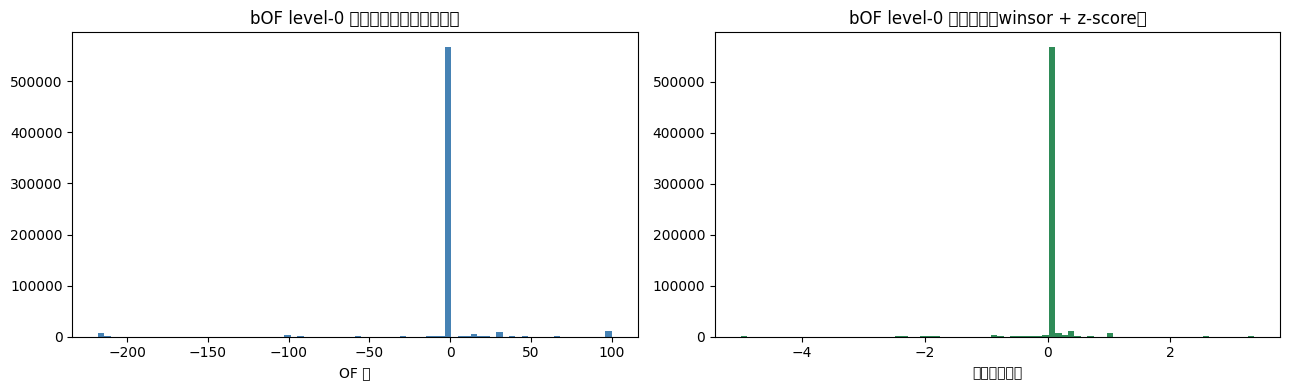

已保存 → results/of_distribution.png


In [12]:
# ── 可视化：OF 标准化前后分布对比（演示市场，bid level-0）────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
raw0  = market_data[demo_key]["of"][:, 0]
norm0 = market_data[demo_key]["of_norm"][:, 0]

axes[0].hist(np.clip(raw0, np.quantile(raw0, 0.01), np.quantile(raw0, 0.99)),
             bins=80, color="steelblue")
axes[0].set_title("bOF level-0 原始分布（非平稳尺度）")
axes[0].set_xlabel("OF 值")

axes[1].hist(np.clip(norm0, -5, 5), bins=80, color="seagreen")
axes[1].set_title("bOF level-0 标准化后（winsor + z-score）")
axes[1].set_xlabel("标准化后的值")

plt.tight_layout()
Path("../results").mkdir(exist_ok=True)
plt.savefig("../results/of_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("已保存 → results/of_distribution.png")

## 总结

本 notebook 完成：
1. ✅ 从 14 个可用合约的订单簿构建了论文式 **OF 特征**（20 维，bid+ask 各 10 档）
2. ✅ 计算了多 horizon 的 mid-price return 预测目标
3. ✅ 按时间顺序切分 train/val/test（防 look-ahead）
4. ✅ Winsorization + Z-score（只用训练集参数）
5. ✅ 提供 `make_windows` 即时窗口化（100×20），避免内存爆炸
6. ✅ 存盘到 `data/processed/of/`

**下一步（建模 notebook）：** 加载 `data/processed/of/*.npz`，用 `make_windows` 生成
`(N, 100, 20)` 输入，训练 MLP / LSTM / CNN-LSTM，用 $R^2_{OS}$ 对比 naive 基准。